# Advanced topics

![Status](https://img.shields.io/static/v1.svg?label=Status&message=Finished&color=green)

**Author:** Egor Trushin  
**Date created:**  18/07/2025  
**Last modified:**  04/09/2026

## 1. Introduction

Advanced tricks and topics are reviewed here.

In [1]:
import sys

sys.path.insert(0, "..")

import matplotlib.pyplot as plt
import numpy as np
import scipy
from pyscf import cc, df, dft, gto, scf

from methods.exxoep import EXXOEP
from methods.ksinv import KSINV
from methods.osdftoep import OSDFTOEP
from methods.osexxoep import OSEXXOEP
from utils.coulomb_potential_on_grid import coulomb_potential_on_grid
from utils.gen_coords_1d import gen_coords_1d
from utils.relaxed_ccsd import cc_rrdm1

In [2]:
# Function to make text in bold
def bold_text(text):
    return "\033[1m" + text + "\033[0m"


def print_eigs(eigs, no, nmax):
    """Function to print eigenvalues, HOMO energy, and LUMO-HOMO gap.

    Args:
      eig: Eigenvalues.
      no: Number of occupied orbitals.
      nmax: Number of eigenvalues to print.
    """
    if len(eigs.shape) == 1:  # closed-shell case
        for i in range(nmax):
            eig = f"{eigs[i]:7.3f}"
            if i + 1 <= no:
                eig = bold_text(eig)
            print(f"{i + 1:2}   {eig}")
        print(f"HOMO:      {eigs[no - 1]:7.3f}")
        print(f"LUMO-HOMO: {eigs[no] - eigs[no - 1]:7.3f}")
    else:
        for i in range(nmax):
            ea = f"{eigs[0, i]:7.3f}"
            eb = f"{eigs[1, i]:7.3f}"
            if i + 1 <= no[0]:
                ea = bold_text(ea)
            if i + 1 <= no[1]:
                eb = bold_text(eb)
            if i + 1 <= nmax:
                print(f"{i + 1:2}   {ea}  {eb}")
        print(f"HOMO:       {eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1] - 1]:7.3f}")
        print(f"LUMO-HOMO:  {eigs[0, no[0]] - eigs[0, no[0] - 1]:7.3f}   {eigs[1, no[1]] - eigs[1, no[1] - 1]:7.3f}")

## 2. Counteraction of electric field by EXX-OEP: example of hydrogen chain
> E. Trushin, R. Mandalia, A. Görling. Analyzing the response of exchange–correlation potentials of chain-like molecules to electric fields by Kohn–Sham inversion and evaluation of the response within the random phase approximation -- J. Chem. Phys. 163, 244115 (2025). https://doi.org/10.1063/5.0294687

In [3]:
def hydrogen_chain(n_mols, r1=1.058354498, r2=1.587531747, centered=True):
    r"""
    Creates list with coordinates of hydrogen atoms.

    Args:
        n_mols: number of h2 molecules
        r1: itermolecular bond length
        r2: intramolecular bond length
        centered: detemines whether geometry is centered with respect to z=0 or not
    """
    z = [0.0]
    for _ in range(n_mols):
        z.append(z[-1] + r1)
        z.append(z[-1] + r2)
    z.pop()  # remove last element

    if centered:
        shift = z[-1] / 2.0
        for i in range(len(z)):
            z[i] -= shift

    return z


def hydrogen_chain_pyscf(n_mols, r1=1.058354498, r2=1.587531747, centered=True):
    r"""
    Creates text with geometry to use in PySCF.

    Args:
        n_mols: number of h2 molecules
        r1: itermolecular bond length
        r2: intramolecular bond length
        centered: detemines whether geometry is centered with respect to z=0 or not
    """

    z = hydrogen_chain(n_mols, r1, r2, centered)

    geom = ""
    for x in z:
        geom += f"H 0. 0. {x}; "

    return geom[:-2]

In [4]:
def lda_vxc(mol, coords, dm, xc):
    """Evaluate the LDA exchange-correlation potential on a given real-space grid.

    Args:
      mol: PySCF molecule object
      coords: coordinates of grid on which the potential will be calculated
      dm: density matrix
      xc: xc string, i.e. xc='lda'

    Returns:
      vxc: exchange-correlation potential on grid
    """
    ao_value = dft.numint.eval_ao(mol, coords, deriv=0)
    rho = dft.numint.eval_rho(mol, ao_value, dm, xctype="LDA")
    _, vxc = dft.libxc.eval_xc(xc, rho)[:2]
    return vxc[0]

In [5]:
N_MOLS = 3
ELECTRIC_FIELD = [0.0, 0.0, -0.001]
coords = gen_coords_1d(-25.0, 25.0, 1000)

In [6]:
mol = gto.M(atom=hydrogen_chain_pyscf(n_mols=N_MOLS), basis="aug-cc-pVQZ", symmetry=False)
mol.verbose = 0

# LDA calculation without field
mf = dft.RKS(mol, xc="LDA, VWN").density_fit().run()
dm = mf.make_rdm1()
vxc_lda_without_field = lda_vxc(mol, coords, dm, "LDA, VWN")

# LDA calculation with field
mf = dft.RKS(mol, xc="LDA, VWN").density_fit()
field = np.einsum("x,xij->ij", ELECTRIC_FIELD, mol.intor("int1e_r"))
h1 = mf.get_hcore() + field
mf.get_hcore = lambda *args, **kwargs: h1
mf.run()
dm = mf.make_rdm1()
vxc_lda_with_field = lda_vxc(mol, coords, dm, "LDA, VWN")

In [7]:
mol = gto.M(atom=hydrogen_chain_pyscf(n_mols=N_MOLS), basis="aug-cc-pV6Z", symmetry=False)
mol.verbose = 0

# EXX-OEP calculation without field

mf = scf.RHF(mol).density_fit().run()

mf_oep = EXXOEP(mf, "aug-cc-pVDZ-RIFIT")
mf_oep.run(maxit=15, thr_fai_oep=1e-3)

vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vx_on_grid_without_field = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vref_oep)

# EXX-OEP calculation with field

mf = scf.RHF(mol).density_fit()
field = np.einsum("x,xij->ij", ELECTRIC_FIELD, mol.intor("int1e_r"))
h1 = mf.get_hcore() + field
mf.get_hcore = lambda *args, **kwargs: h1
mf.run()

mf_oep = EXXOEP(mf, "aug-cc-pVDZ-RIFIT")
mf_oep.run(maxit=15, thr_fai_oep=1e-3)

vcoul_on_grid = coulomb_potential_on_grid(mf_oep.pmol, coords)
vx_on_grid_with_field = vcoul_on_grid @ (mf_oep.vrest_oep + mf_oep.vref_oep)

ITER        ENERGY               EDIFF
  0     -3.259535790349
  1     -3.259657465112     -0.000121674762
  2     -3.259667273693     -0.000009808582
  3     -3.259669666345     -0.000002392651
  4     -3.259669685893     -0.000000019548
  5     -3.259669692528     -0.000000006635
SCF converged
ITER        ENERGY               EDIFF
  0     -3.259564066869
  1     -3.259685727118     -0.000121660249
  2     -3.259695541451     -0.000009814333
  3     -3.259697933175     -0.000002391723
  4     -3.259697952747     -0.000000019572
  5     -3.259697959368     -0.000000006621
SCF converged


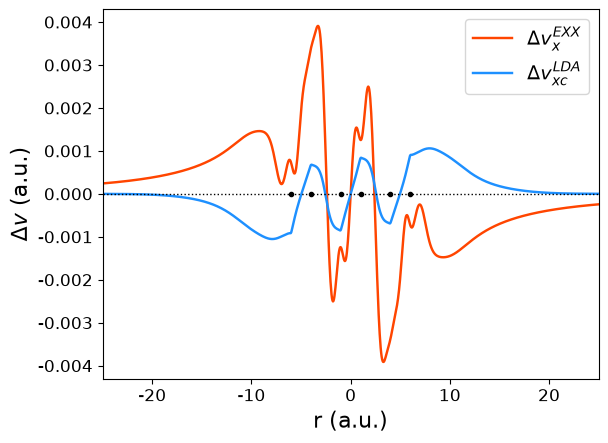

In [8]:
plt.plot(coords[:, 2], vx_on_grid_without_field - vx_on_grid_with_field, color="orangered", label="$\\Delta v_x^{EXX}$")
plt.plot(coords[:, 2], vxc_lda_without_field - vxc_lda_with_field, color="dodgerblue", label="$\\Delta v_{xc}^{LDA}$")
plt.axhline(y=0.0, color="k", linestyle=":", linewidth=1)
atoms = hydrogen_chain(N_MOLS, r1=2, r2=3)
plt.plot(atoms, len(atoms) * [0.0], "o", color="black", markersize=3)
plt.xlim(-25, 25)
plt.ylabel("$\\Delta v$ (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend()
plt.show()

## 3. Example of obtaining an EXX-OEP solution for an oxygen atom that violates the $v$-representability condition in the spin-restricted case
> E. Trushin, J. Erhard, A. Görling. Violations of the $v$-representability condition underlying Kohn-Sham density-functional theory -- Phys. Rev. A 110 (2024) L020802. https://doi.org/10.1103/PhysRevA.110.L020802

In [9]:
class OSEXXOEP_with_swap(OSEXXOEP):
    """OSEXXOEP with swap of 3rd and 5th orbitals in beta spin-channel."""

    def get_energies_and_potentials(self):
        """Determines energy contributions and potentials."""

        self.mf.mo_coeff[1][:, [2, 4]] = self.mf.mo_coeff[1][:, [4, 2]]
        self.mf.mo_energy[1][[2, 4]] = self.mf.mo_energy[1][[4, 2]]

        dm = self.mf.make_rdm1()
        h1e = self.mf.get_hcore()
        e1 = np.einsum("ij,ji->", h1e, dm[0]).real
        e1 += np.einsum("ij,ji->", h1e, dm[1]).real
        self.vj_ao, self.vxnl_ao = self.mf.get_jk(dm)

        self.vj_ao = self.vj_ao[0] + self.vj_ao[1]
        self.E_Coul = np.einsum("ij,ji->", self.vj_ao, dm[0] + dm[1]).real * 0.5
        self.E_x = -0.5 * np.einsum("ij,ji->", self.vxnl_ao[0], dm[0]).real
        self.E_x += -0.5 * np.einsum("ij,ji->", self.vxnl_ao[1], dm[1]).real
        self.e_tot = e1 + self.E_Coul + self.E_x + self.mf.energy_nuc()
        self.vxnl_ao *= -1.0

In [10]:
ORBITAL_BASIS = "aug-cc-pwCVQZ"
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
DFIT_BASIS = "aug-cc-pwCV5Z-RIFIT"
GEOM = "O 0.000000    0.000000  0.000000"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=2)
mol.verbose = 0
mol.symmetry = False

mf = scf.UHF(mol).density_fit(auxbasis=DFIT_BASIS).run()

mf_oep = OSEXXOEP_with_swap(mf, OEP_BASIS, spin_sym=True)
mf_oep.run(maxit=30, thr_fai_oep=1.7e-2, e_conv_thr=1e-12)

print_eigs(mf_oep.mf.mo_energy, mf_oep.mf.nelec, 10)

ITER        ENERGY               EDIFF
  0    -74.732802446203
  1    -74.805864926556     -0.073062480353
  2    -74.807463316537     -0.001598389982
  3    -74.807566339617     -0.000103023080
  4    -74.807568061167     -0.000001721550
  5    -74.807568069927     -0.000000008759
  6    -74.807568067247      0.000000002680
  7    -74.807568067176      0.000000000071
  8    -74.807568067177     -0.000000000001
  9    -74.807568067181     -0.000000000004
 10    -74.807568067181     -0.000000000000
SCF converged
 1   -19.185  -19.185
 2    -1.161   -1.161
 3    -0.607   -0.579
 4    -0.607   -0.607
 5    -0.579   -0.607
 6    -0.126   -0.126
 7    -0.078   -0.078
 8    -0.078   -0.078
 9    -0.074   -0.074
10     0.161    0.161
HOMO:        -0.579    -0.579
LUMO-HOMO:    0.453    -0.028


## 4. Singlet excited states in OSDFTOEP calculations via orbital swapping

In [11]:
class OSDFTOEP_with_swap(OSDFTOEP):
    """OSDFTOEP with swap of orbitals in beta spin-channel."""

    def __init__(
        self,
        mf,
        oep_basis,
        use_HOMO_condition=False,
        vh_via_OEP=False,
        space_sym=False,
        spin_sym=False,
        xc_homo=None,
        ip_first_iter=False,
        swap=None,
    ):

        self.swap = swap
        super().__init__(mf, oep_basis, use_HOMO_condition, vh_via_OEP, space_sym, spin_sym, xc_homo, ip_first_iter)

    def get_energies_and_potentials(self):
        """Determines energy contributions and potentials."""

        is_hybrid = dft.libxc.is_hybrid_xc(self.mf.xc)
        if is_hybrid:
            hybrid_coeff = dft.libxc.hybrid_coeff(self.mf.xc)

        # swap orbitals and eigenvalues
        i, j = self.swap[0] - 1, self.swap[1] - 1
        self.mf.mo_coeff[1][:, [i, j]] = self.mf.mo_coeff[1][:, [j, i]]
        self.mf.mo_energy[1][[i, j]] = self.mf.mo_energy[1][[j, i]]

        self.mf.max_cycle = 0
        self.mf.run()
        self.e_tot = self.mf.e_tot

        self.vj_ao, self.vxnl_ao = self.mf.get_jk()

        dm = self.mf.make_rdm1()
        self.vj_ao = self.vj_ao[0] + self.vj_ao[1]
        self.E_Coul = np.einsum("ij,ji->", self.vj_ao, dm[0] + dm[1]).real * 0.5
        _, _, vxc = dft.numint.nr_vxc(self.mf.mol, self.mf.grids, self.mf.xc, dm, spin=1)

        if is_hybrid:
            self.E_x = -0.5 * np.einsum("ij,ji->", self.vxnl_ao[0], dm[0]).real
            self.E_x += -0.5 * np.einsum("ij,ji->", self.vxnl_ao[1], dm[1]).real
            self.vxnl_ao *= -1.0

        if is_hybrid:
            self.vxnl_ao = vxc + hybrid_coeff * self.vxnl_ao
        else:
            self.vxnl_ao = vxc

In [12]:
ORBITAL_BASIS = "d-aug-cc-pV5Z"  # double augmentation to better represent Rydberg orbitals
OEP_BASIS = "aug-cc-pVDZ-RIFIT"
DFIT_BASIS = "aug-cc-pV5Z-RIFIT"
GEOM = "He 0.000000    0.000000  0.000000"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS, spin=0)
mol.verbose = 0
mol.symmetry = False

In [13]:
mf = dft.UKS(mol, xc="pbe").density_fit(auxbasis=DFIT_BASIS)
mf.grids.level = 4
mf.run()

mf_oep = OSDFTOEP_with_swap(mf, OEP_BASIS, spin_sym=True, swap=[1, 2])
mf_oep.run(maxit=30, thr_fai_oep=5e-3, e_conv_thr=1e-12)

print_eigs(mf_oep.mf.mo_energy, mf_oep.mf.nelec, 10)

ITER        ENERGY               EDIFF
  0     -2.158989034198
  1     -2.162512329477     -0.003523295279
  2     -2.162571318006     -0.000058988529
  3     -2.162536537679      0.000034780328
  4     -2.162534514610      0.000002023068
  5     -2.162534638194     -0.000000123584
  6     -2.162534639968     -0.000000001774
  7     -2.162534639968      0.000000000001
SCF converged
 1    -1.166   -0.192
 2    -0.192   -1.166
 3    -0.141   -0.141
 4    -0.141   -0.141
 5    -0.141   -0.141
 6    -0.073   -0.073
 7     0.033    0.033
 8     0.033    0.033
 9     0.033    0.033
10     0.033    0.033
HOMO:        -1.166    -0.192
LUMO-HOMO:    0.973    -0.973


In [14]:
mf = dft.UKS(mol, xc="pbe").density_fit(auxbasis=DFIT_BASIS)
mf.grids.level = 4
mf.run()

mf_oep = OSDFTOEP_with_swap(mf, OEP_BASIS, spin_sym=True, swap=[1, 6])
mf_oep.run(maxit=30, thr_fai_oep=5e-3, e_conv_thr=1e-12)

print_eigs(mf_oep.mf.mo_energy, mf_oep.mf.nelec, 10)

ITER        ENERGY               EDIFF
  0     -2.077751719791
  1     -2.078285825258     -0.000534105467
  2     -2.078231727319      0.000054097939
  3     -2.078265623130     -0.000033895811
  4     -2.078270895406     -0.000005272275
  5     -2.078270970954     -0.000000075548
  6     -2.078270972377     -0.000000001422
  7     -2.078270972367      0.000000000010
  8     -2.078270972364      0.000000000003
  9     -2.078270972352      0.000000000013
 10     -2.078270972364     -0.000000000012
 11     -2.078270972364     -0.000000000000
SCF converged
 1    -1.405   -0.125
 2    -0.297   -0.297
 3    -0.246   -0.246
 4    -0.246   -0.246
 5    -0.246   -0.246
 6    -0.125   -1.405
 7    -0.058   -0.058
 8    -0.058   -0.058
 9    -0.058   -0.058
10    -0.058   -0.058
HOMO:        -1.405    -0.125
LUMO-HOMO:    1.109    -0.171


FCI results are -2.145481194824 and -2.062782549749

## 5. Kohn-Sham inversion using reference density in OEP representation

In [15]:
# HF and CCSD calculations

ORBITAL_BASIS = "aug-cc-pwCVTZ"
GEOM = "C 0.000000    0.000000   -0.646514; O 0.000000    0.000000    0.484886"

mol = gto.M(atom=GEOM, basis=ORBITAL_BASIS)
mol.verbose = 0
mol.symmetry = False

mf = scf.RHF(mol).density_fit().run()
print(f"Hartree-Fock total energy: {mf.e_tot:15.12f}")

mf_cc = cc.CCSD(mf)
mf_cc.kernel()
print(
    f"CCSD correlation energy:     {mf_cc.e_corr:15.12f}",
)
print(f"CCSD total energy:         {mf_cc.e_tot:15.12f}")
dm_ccsd_unrelaxed = mf_cc.make_rdm1(ao_repr=True)
dm_ccsd = cc_rrdm1(mf_cc)

Hartree-Fock total energy: -112.781910558457
CCSD correlation energy:     -0.469283706757
CCSD total energy:         -113.251194265214


In [16]:
# Generate integration grid
grid = dft.gen_grid.Grids(mol)
grid.level = 5
grid.build()

# Store CCSD density on grid
ao_grid = dft.numint.eval_ao(mol, grid.coords)
density_on_grid = dft.numint.eval_rho(mol, ao_grid, dm_ccsd)

In [17]:
# Construct reference density in OEP representation
ao_grid = dft.numint.eval_ao(mol, grid.coords)
auxmol = df.addons.make_auxmol(mol, "aug-cc-pVDZ-RIFIT")
V = coulomb_potential_on_grid(auxmol, grid.coords)
t_ref = (grid.weights * density_on_grid) @ V

In [18]:
# Class for KS inversion with reference density in OEP representation


class KSINV_t_ref(KSINV):
    r"""
    Implements response function Kohn-Sham inversion method for closed-shell systems.

    This implementation uses reference density constructed in OEP representation instead
    of density matrix in AO representation.

    Args:
        mf: PySCF object with RHF or RKS calculation
        oep_basis: auxiliary basis to solve OEP equation
        t_ref: reference (target) density in OEP representation
        ip: ionization potential (IP), if provided HOMO condition to enforce this IP is employed
        space_sym: whether to perform space-symmetrization
    """

    def __init__(self, mf, oep_basis, t_ref, ip=None, space_sym=False):
        self.t_ref = t_ref
        self.ip = ip
        self.use_HOMO_condition = ip is not None
        self.nelec = sum(i != 0 for i in mf.mo_occ)
        self.init_common(mf, oep_basis, True, space_sym)
        self.get_inverse_WII()

    def run(self, maxit=100, thr_fai_oep=5e-2, conv_thr=1e-10, mixing_a=0.1, mixing_i=3, grid_weights=None):
        r"""
        Performs a KS inversion calculation.

        Args:
            maxit: maximal number of iterations
            thr_fai_oep: threshold T_{ai} from Section IIA5 of J. Chem. Phys. 155 (2021) 054109
            conv_thr: threshold for convergence
            grid_weights: optional tuple (coords, weights, rho_ref) for real-space density difference
                          monitoring; coords are grid coordinates, weights are integration weights,
                          rho_ref is the reference density on the grid
        """

        vrest_oep = None
        vrest_ao = None
        delta_rhs_i = None

        h1e = self.mf.get_hcore()

        vc2 = self.WII.T @ self.t_ref
        vc = self.WII @ vc2
        vref_oep = -1.0 / np.dot(self.y, vc) * vc
        vref_ao = np.einsum("ijk,k->ij", self.ints_3c_ao.transpose(1, 2, 0), vref_oep[:])
        vaux = 2 * self.nelec / np.dot(self.y, vc) * vc
        vj_ao_ref = np.einsum("ijk,k->ij", self.ints_3c_ao.transpose(1, 2, 0), vaux[:])

        F = h1e + vj_ao_ref + vref_ao
        S = self.mf.get_ovlp()
        self.mf.mo_energy, self.mf.mo_coeff = self.mf._eigh(F, S)

        if grid_weights is not None:
            gcoords, gweights, rho_ref = grid_weights
            ao_on_grid = dft.numint.eval_ao(self.mf.mol, gcoords)
            print("ITER" + " " * 8 + "RHS" + " " * 8 + "MIXING" + " " * 6 + "|Δn|")
        else:
            print("ITER" + " " * 8 + "RHS" + " " * 8 + "MIXING")
        for current_iter in range(maxit):
            dm = self.mf.make_rdm1()
            e1 = np.einsum("ij,ji->", h1e, dm)

            e_kin = np.einsum("ij,ji->", self.mf.mol.intor_symmetric("int1e_kin"), dm)
            e_ext = np.einsum("ij,ji->", self.mf.mol.intor_symmetric("int1e_nuc"), dm)

            vj_ao, vxnl_ao = self.mf.get_jk(dm=np.asarray(dm))
            e_coul = np.einsum("ij,ji->", vj_ao, dm) * 0.5
            e_x = -0.5 * np.einsum("ij,ji->", vxnl_ao, dm) * 0.5
            e_ext = np.einsum("ij,ji->", self.mf.mol.intor_symmetric("int1e_nuc"), dm)
            e_kin = np.einsum("ij,ji->", self.mf.mol.intor_symmetric("int1e_kin"), dm)

            ints_3c = self.mf.mo_coeff.T @ self.ints_3c_ao @ self.mf.mo_coeff

            if self.space_sym:
                vc2 = self.WII.T @ self.t_ref
                vc = self.WII @ vc2
                vaux = 2 * self.nelec / np.dot(self.y, vc) * vc
                vj_ao_ref = np.einsum("ijk,k->ij", self.ints_3c_ao.transpose(1, 2, 0), vaux[:])

            if self.use_HOMO_condition:
                z, zII = self.get_z_and_zII(ints_3c, self.mf.mo_energy, self.nelec)
                vref_oep = self.get_v_ref_w_homo(self.t_ref, vj_ao_ref, zII, self.mf.mo_coeff, self.nelec, self.ip)
                vref_ao = np.einsum("ijk,k->ij", self.ints_3c_ao.transpose(1, 2, 0), vref_oep[:])
                W3 = self.get_W3_charge_and_homo(zII)
            else:
                W3 = self.get_W3_charge()

            W = self.get_W(W3, ints_3c, self.nelec, thr_fai_oep)
            W_inv = self.get_inverse_W(W3, ints_3c, self.nelec, thr_fai_oep)
            self.unity_test(W, W_inv)

            X0 = 4.0 * self.get_X0(ints_3c, self.mf.mo_energy, self.nelec, W)

            rhs = self.get_rhs_inv(W)
            delta_rhs = np.sqrt(np.dot(rhs, rhs))

            rhs = scipy.linalg.solve(X0, rhs)

            rhs_exx = self.get_rhs(vref_ao, -0.5 * vxnl_ao, ints_3c, self.mf.mo_coeff, self.mf.mo_energy, self.nelec, W)
            rhs_exx = scipy.linalg.solve(0.25 * X0, rhs_exx)
            self.vx_oep = W @ rhs_exx + vref_oep

            mixing, delta_rhs_i = self.get_mixing(current_iter, delta_rhs, mixing_a, mixing_i, delta_rhs_i)

            if vrest_oep is None:
                vrest_oep = mixing * W @ rhs
            else:
                vrest_oep += mixing * W @ rhs

            vrest_oep = W @ (W_inv @ vrest_oep)

            vrest_ao = np.einsum("ijk,k->ij", self.ints_3c_ao.transpose(1, 2, 0), vrest_oep[:])

            self.potentials_test(
                vrest_oep,
                vref_oep,
                vrest_ao,
                vref_ao,
                vj_ao_ref,
                self.mf.mo_coeff,
                self.nelec,
                z if self.use_HOMO_condition else None,
            )

            F = h1e + vj_ao_ref + vref_ao + vrest_ao
            self.mf.mo_energy, self.mf.mo_coeff = self.mf._eigh(F, S)

            if grid_weights is not None:
                rho_ks = dft.numint.eval_rho(self.mf.mol, ao_on_grid, self.mf.make_rdm1())
                drho_norm = np.dot(np.abs(rho_ref - rho_ks), gweights)
                print(f"{current_iter:3}    {delta_rhs:.3e}    {mixing:.3e}    {drho_norm:.3e}")
            else:
                print(f"{current_iter:3}    {delta_rhs:.3e}    {mixing:.3e}")
            if abs(delta_rhs) < conv_thr:
                print("KS inversion converged")
                print()
                print(f"One-electron energy:    {e1:18.12f}")
                print(f"Two-electron energy:    {e_coul + e_x:18.12f}")
                print(f"Nuclear energy:         {self.mf.energy_nuc():18.12f}")
                print(f"Coulomb energy:         {e_coul:18.12f}")
                print(f"Exchange energy:        {e_x:18.12f}")
                print(f"External energy:        {e_ext:18.12f}")
                print(f"Kinetic energy:         {e_kin:18.12f}")

                self.vref_oep = vref_oep
                self.vrest_oep = vrest_oep
                self.vc_oep = vref_oep + vrest_oep - self.vx_oep
                break

            if current_iter == maxit - 1:
                print("KS inversion did not converge")
                self.vref_oep = vref_oep
                self.vrest_oep = vrest_oep

    def get_rhs_inv(self, trans_mat):
        """
        Constructs right-hand side of OEP equation according to
        Eqs. (46)-(48) in J. Chem. Phys. 156, 204124 (2022)
        """
        dm = self.mf.make_rdm1()
        rhs = trans_mat.T @ (self.t_ref - np.einsum("jk,ijk->i", dm, self.ints_3c_ao))
        return rhs

In [19]:
# KS inversion with reference density on OEP representation
mf_inv_t_ref = KSINV_t_ref(mf, "aug-cc-pVDZ-RIFIT", t_ref)
mf_inv_t_ref.run(maxit=100, thr_fai_oep=5e-2, grid_weights=(grid.coords, grid.weights, density_on_grid))

ITER        RHS        MIXING      |Δn|
  0    8.439e-01    1.000e-01    2.155e+00
  1    7.590e-01    1.000e-01    1.943e+00
  2    6.828e-01    1.000e-01    1.752e+00
  3    6.144e-01    1.000e-01    1.580e+00
  4    5.530e-01    1.320e-01    1.375e+00
  5    4.802e-01    1.821e-01    1.131e+00
  6    3.934e-01    2.636e-01    8.430e-01
  7    2.912e-01    3.970e-01    5.227e-01
  8    1.785e-01    5.967e-01    2.295e-01
  9    7.573e-02    8.205e-01    8.507e-02
 10    1.666e-02    9.601e-01    7.309e-02
 11    3.121e-03    9.925e-01    7.252e-02
 12    7.812e-04    9.981e-01    7.244e-02
 13    1.889e-04    9.995e-01    7.243e-02
 14    4.693e-05    9.999e-01    7.243e-02
 15    1.076e-05    1.000e+00    7.243e-02
 16    2.779e-06    1.000e+00    7.243e-02
 17    5.811e-07    1.000e+00    7.243e-02
 18    1.679e-07    1.000e+00    7.243e-02
 19    2.882e-08    1.000e+00    7.243e-02
 20    1.079e-08    1.000e+00    7.243e-02
 21    1.128e-09    1.000e+00    7.243e-02
 22    7.749e-

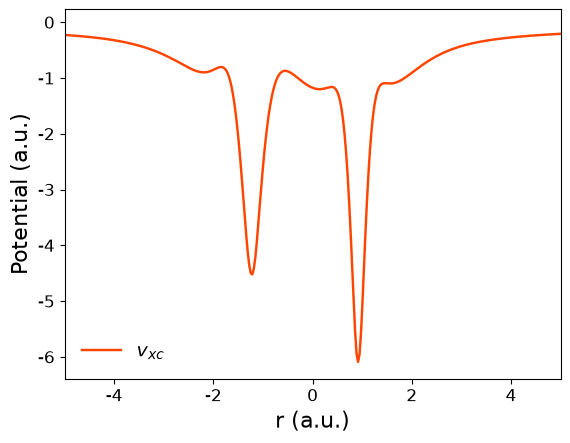

In [20]:
# Plot XC potential

coords = gen_coords_1d(-15.0, 15.0, 1000)
vcoul_on_grid = coulomb_potential_on_grid(mf_inv_t_ref.pmol, coords)
vxc_on_grid_ksinv_t_ref = vcoul_on_grid @ (mf_inv_t_ref.vref_oep + mf_inv_t_ref.vrest_oep)

plt.plot(coords[:, 2], vxc_on_grid_ksinv_t_ref, color="orangered", label="$v_{xc}$")
plt.xlim(-5, 5)
plt.ylabel("Potential (a.u.)", fontsize=16)
plt.xlabel("r (a.u.)", fontsize=16)
plt.legend(frameon=False)
plt.show()
plt.show()

[![Ask questions](https://img.shields.io/static/v1.svg?logo=star&label=❔&message=Ask%20Questions&color=9cf)](https://github.com/EgorTrushin/PyOEP/issues)  For any questions, typos, or bugs that you found, please raise an issue on GitHub.  
[![Star the repository](https://img.shields.io/static/v1.svg?logo=star&label=⭐&message=Star%20the%20Repository&color=yellow)](https://github.com/EgorTrushin/PyOEP/)  If you found this tutorial helpful, consider ⭐-ing the repository.